In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
x = pd.read_csv("/content/car_msrp_cleaned_dataset.csv")

In [ ]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()


In [ ]:
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']
Categorical columns: ['Make', 'Model', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Vehicle Style']


In [ ]:
print(x[num_cols].describe().T)


                   count          mean           std     min       25%  \
Year              9038.0   2010.317659      7.461123  1990.0   2006.00   
Engine HP         9038.0    230.509100     77.855341    66.0    170.00   
Engine Cylinders  9038.0      5.372096      1.386623     3.0      4.00   
Number of Doors   9038.0      3.515269      0.842557     2.0      3.00   
highway MPG       9038.0     26.544313      5.668359    12.5     23.00   
city mpg          9038.0     19.356384      4.346163    10.0     16.00   
Popularity        9038.0   1197.750553    851.268064    21.0    538.50   
MSRP              9038.0  29327.502005  15693.492596  2000.0  20449.25   

                      50%      75%        max  
Year               2014.0   2016.0   2017.000  
Engine HP           220.0    286.5    461.250  
Engine Cylinders      6.0      6.0      8.000  
Number of Doors       4.0      4.0      4.000  
highway MPG          26.0     30.0     40.500  
city mpg             19.0     22.0     31.000

In [ ]:
print("\nSkewness:")
for col in num_cols:
    print(f"{col}: {x[col].skew():.3f}")


Skewness:
Year: -1.165
Engine HP: 0.412
Engine Cylinders: 0.524
Number of Doors: -1.202
highway MPG: 0.287
city mpg: 0.560
Popularity: 0.822
MSRP: 0.082


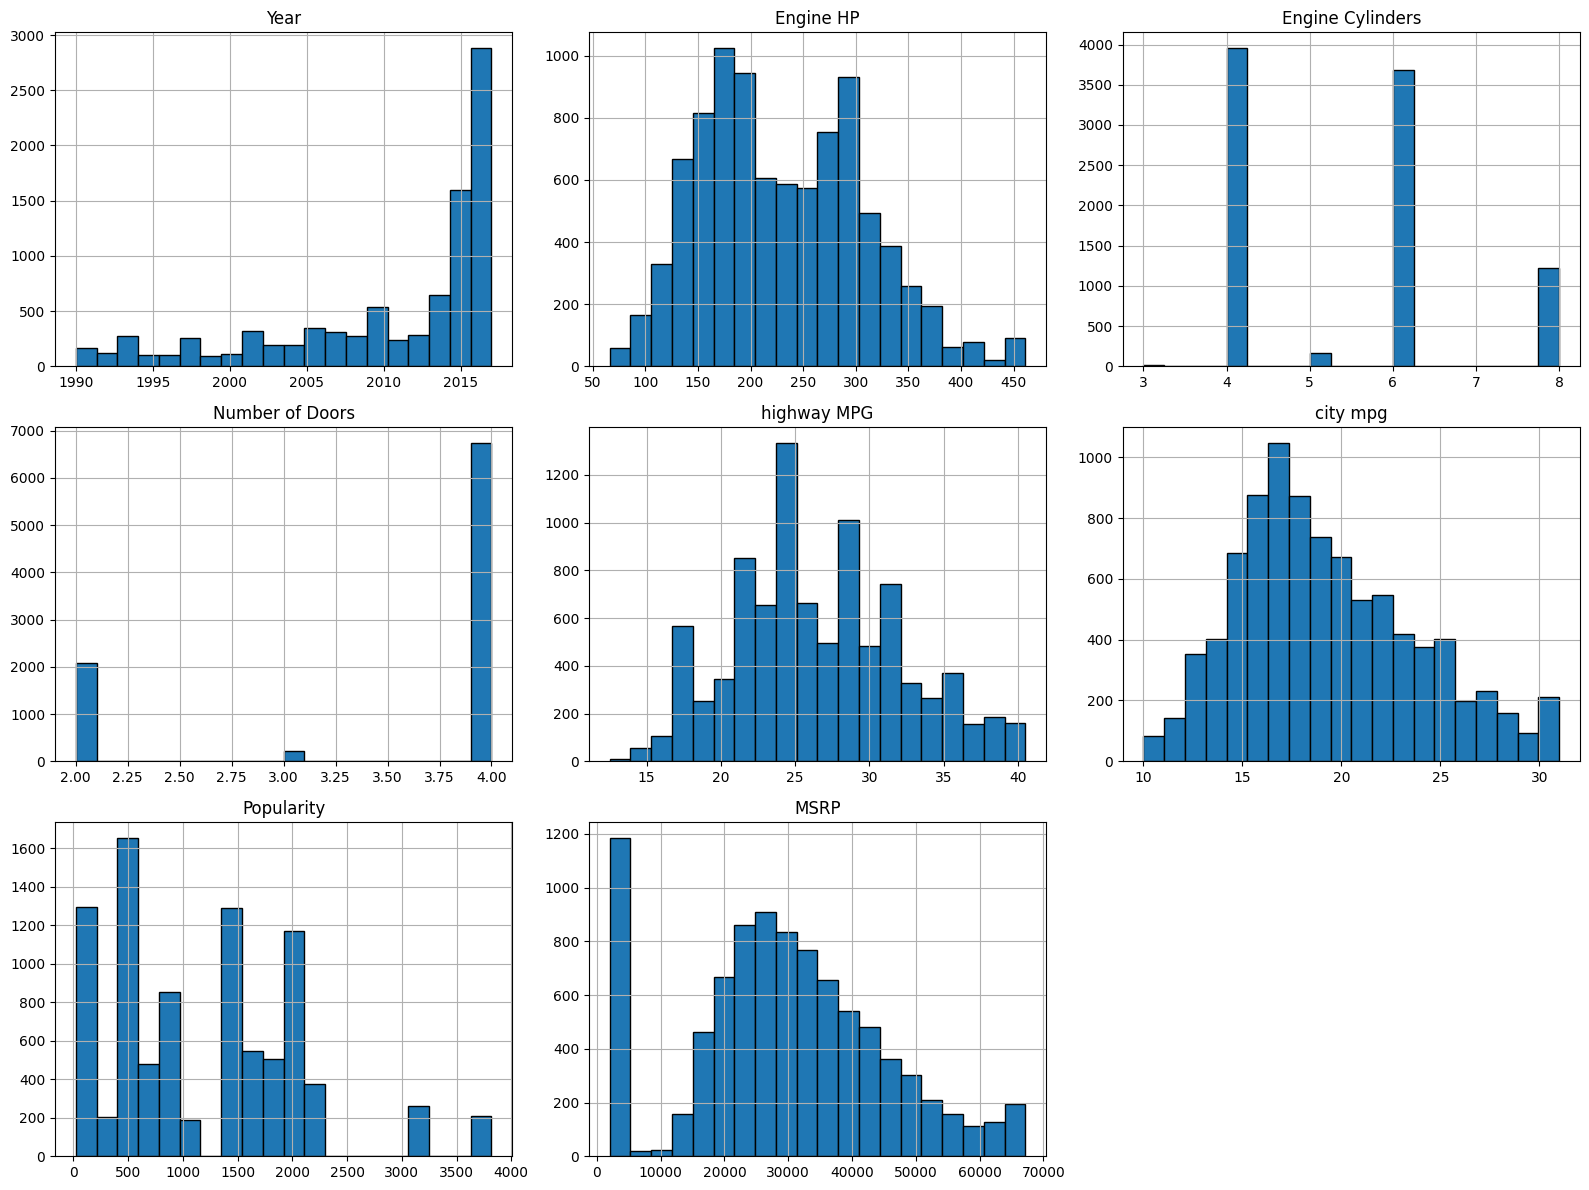

In [ ]:
#Histograms for numeric columns ----

x[num_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


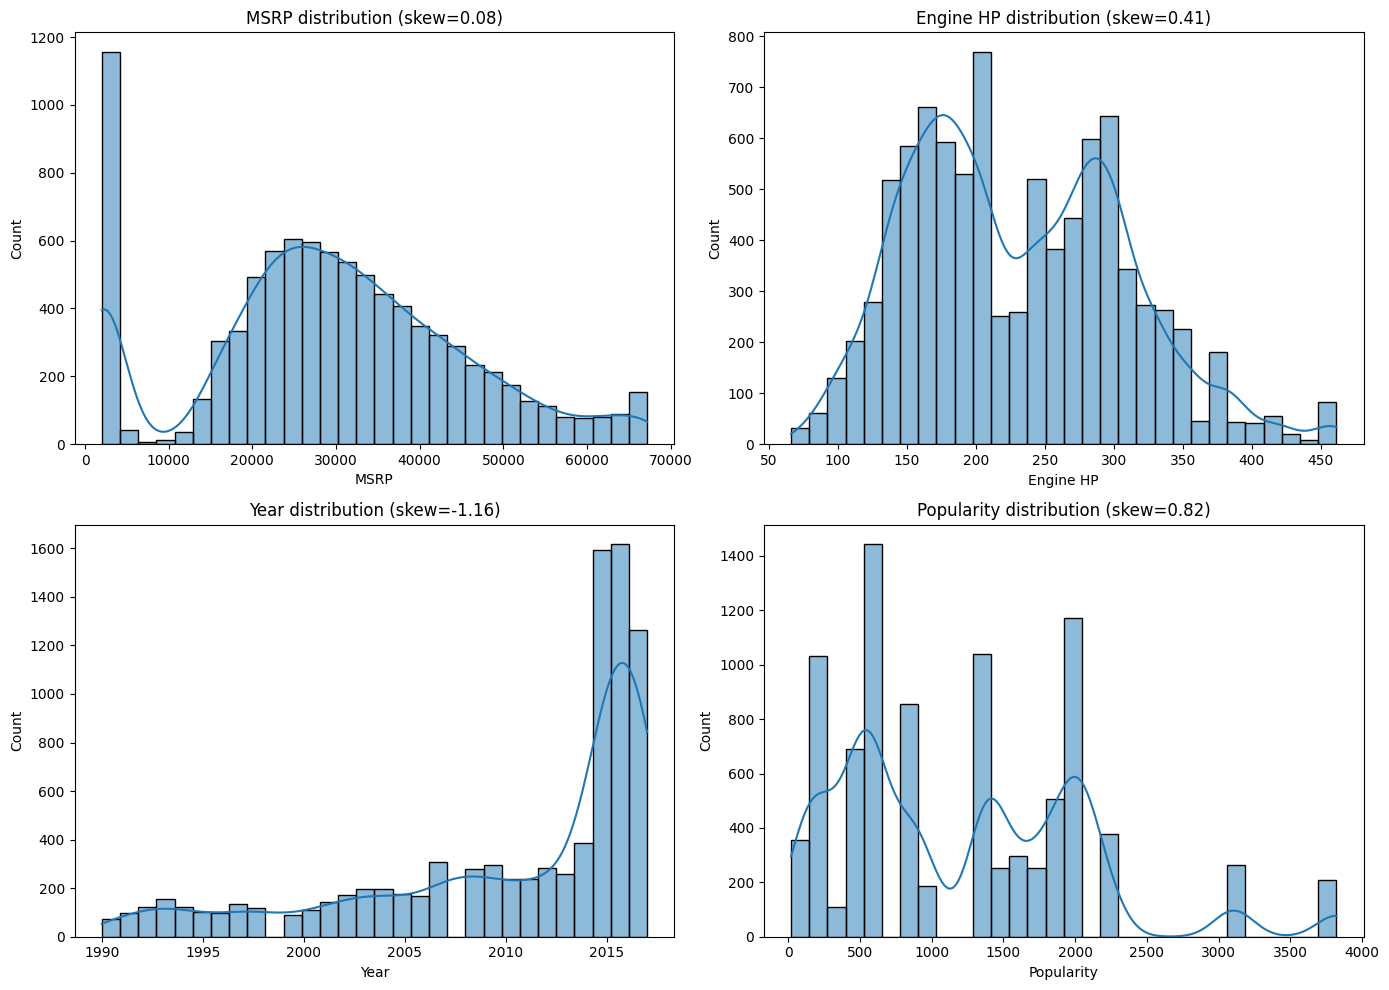

In [ ]:
key_cols = ['MSRP', 'Engine HP', 'Year', 'Popularity']  # adjust as needed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    sns.histplot(x[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'{col} distribution (skew={x[col].skew():.2f})')
plt.tight_layout()
plt.show()

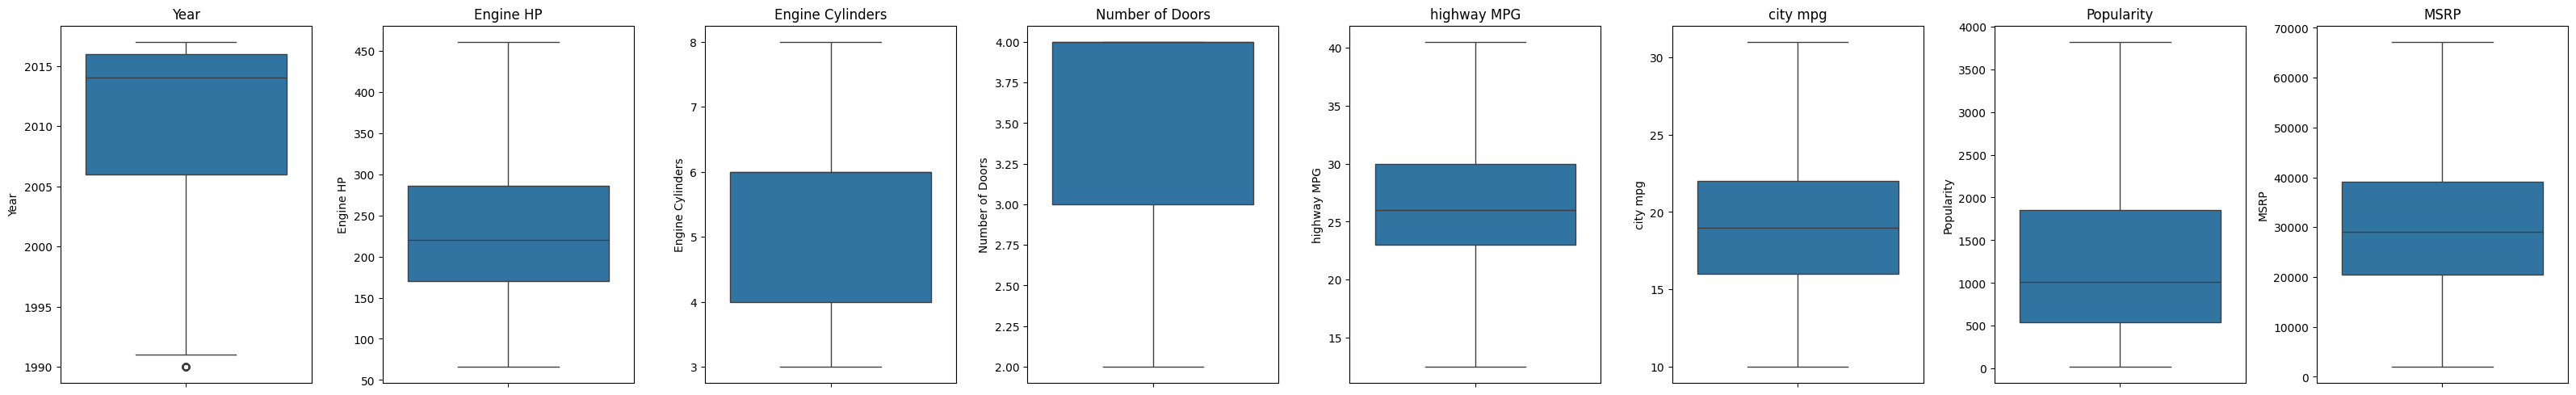

In [ ]:
# ---- 6. Boxplots for numeric columns (spread + outlier view) ----
fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=x[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(x[col].value_counts())
    print(f"Unique values: {x[col].nunique()}")


--- Make ---
Make
Chevrolet        1039
Toyota            640
Nissan            530
Volkswagen        529
Dodge             507
GMC               482
Mazda             408
Honda             377
Suzuki            341
Infiniti          327
Cadillac          296
Volvo             266
Audi              262
Hyundai           252
Acura             239
Subaru            239
Mercedes-Benz     224
Kia               216
BMW               210
Buick             190
Mitsubishi        188
Chrysler          187
Pontiac           181
Lexus             162
Lincoln           145
Oldsmobile        132
Saab              109
Land Rover         91
Plymouth           71
FIAT               59
Scion              55
Porsche            37
Lotus              18
HUMMER             17
Alfa Romeo          5
Maserati            4
Genesis             3
Name: count, dtype: int64
Unique values: 37

--- Model ---
Model
Silverado 1500    156
Tundra            129
Sierra 1500        90
Frontier           76
Accord        

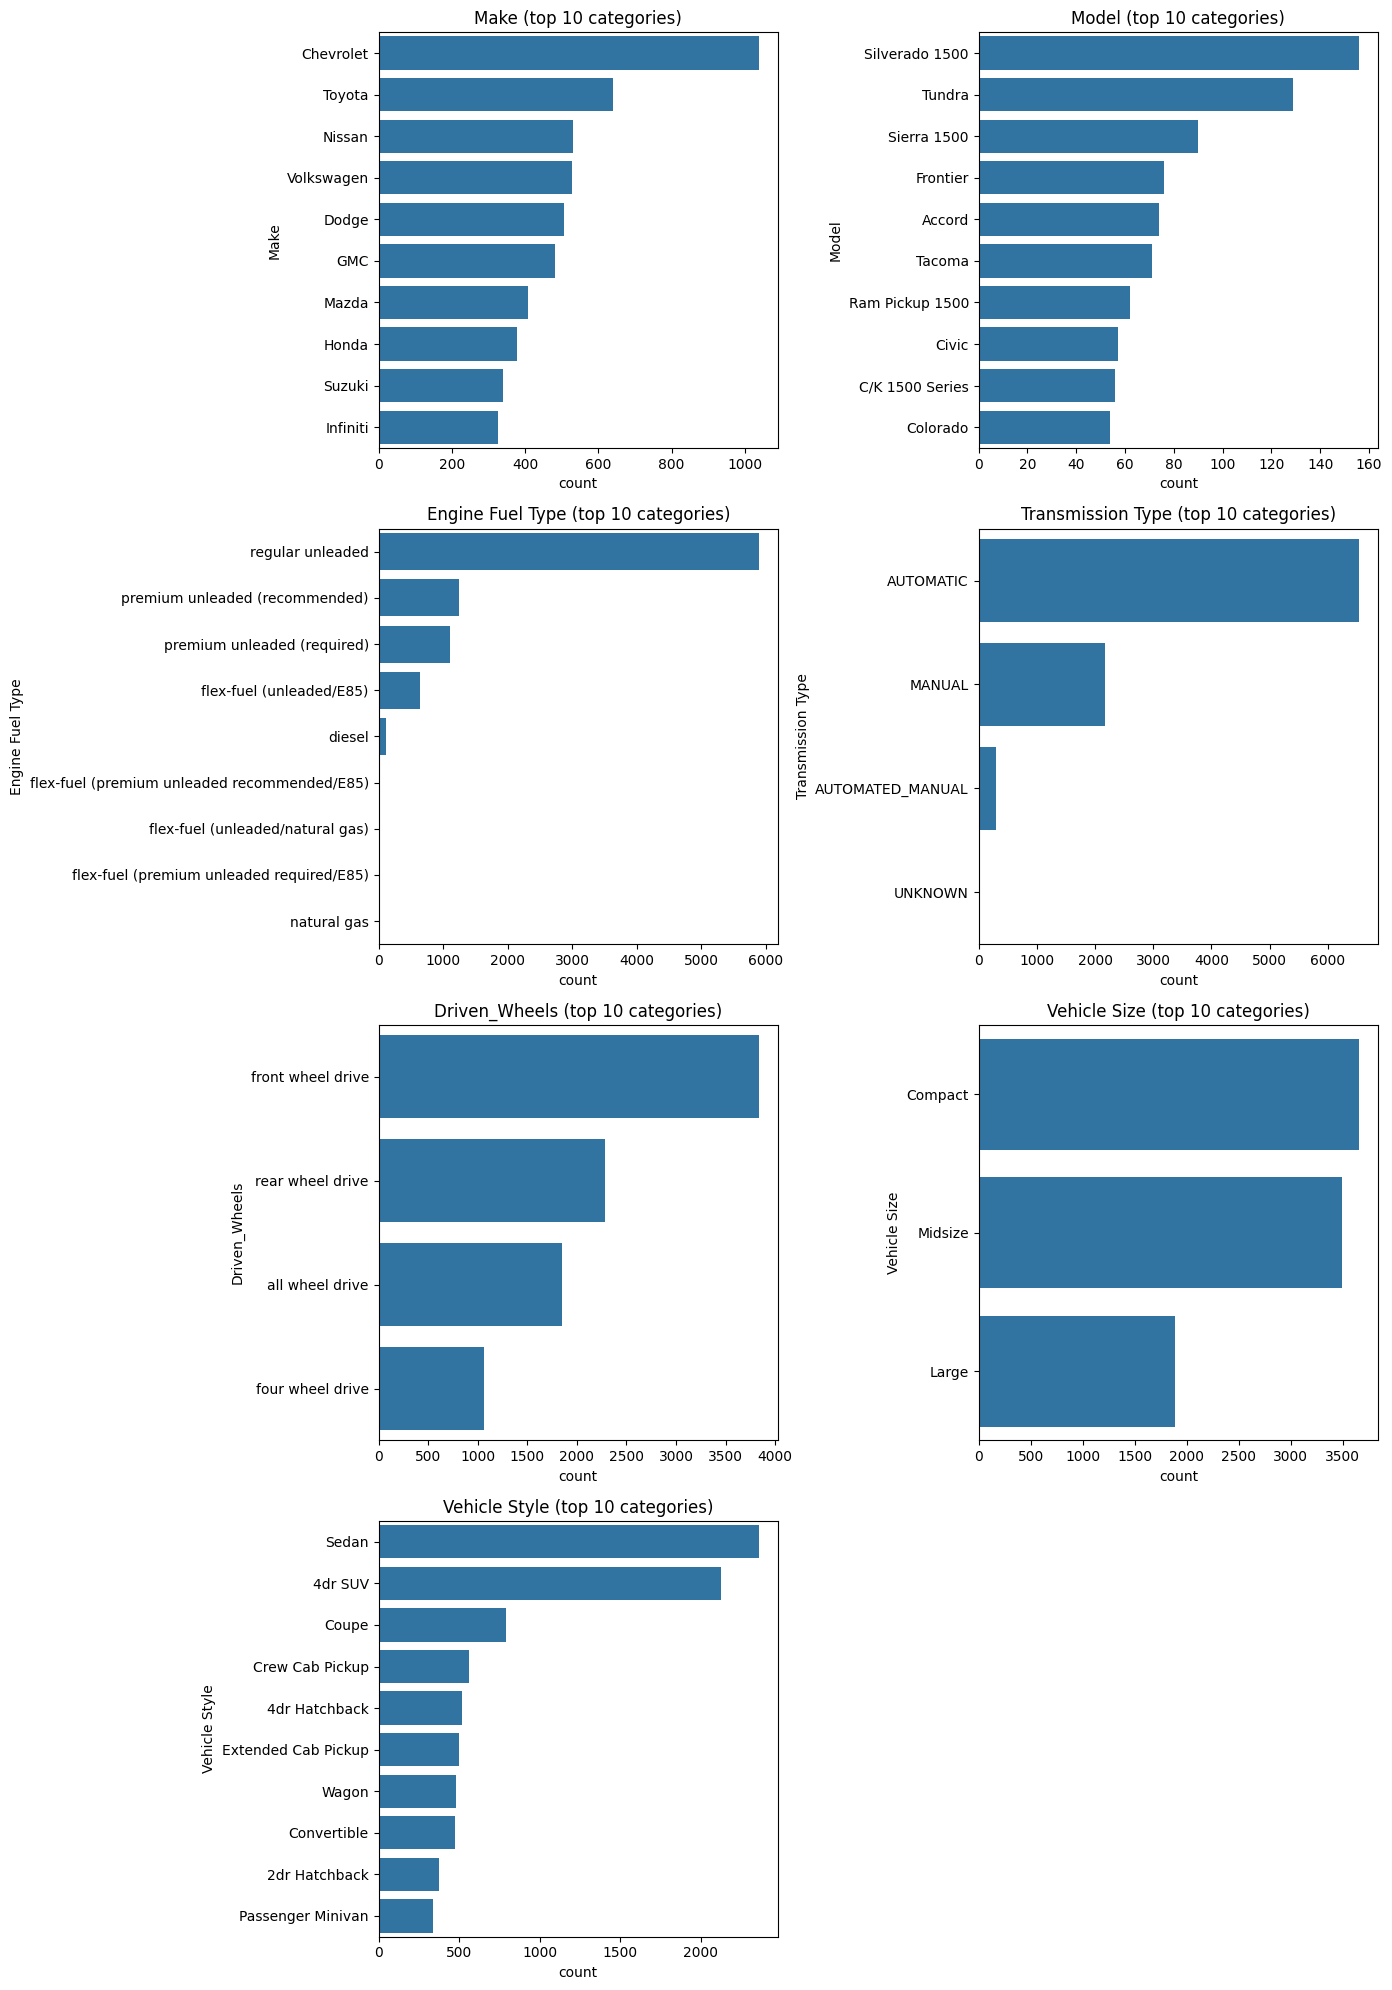

In [ ]:
import math

n = len(cat_cols)
rows = math.ceil(n / 2)
fig, axes = plt.subplots(rows, 2, figsize=(14, 5*rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    order = x[col].value_counts().index[:10]
    sns.countplot(y=x[col], order=order, ax=axes[i])
    axes[i].set_title(f'{col} (top 10 categories)')

# hide any unused subplot slots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()